# BI Query Models

## Ellis SQL

Seems to be the only well working one...

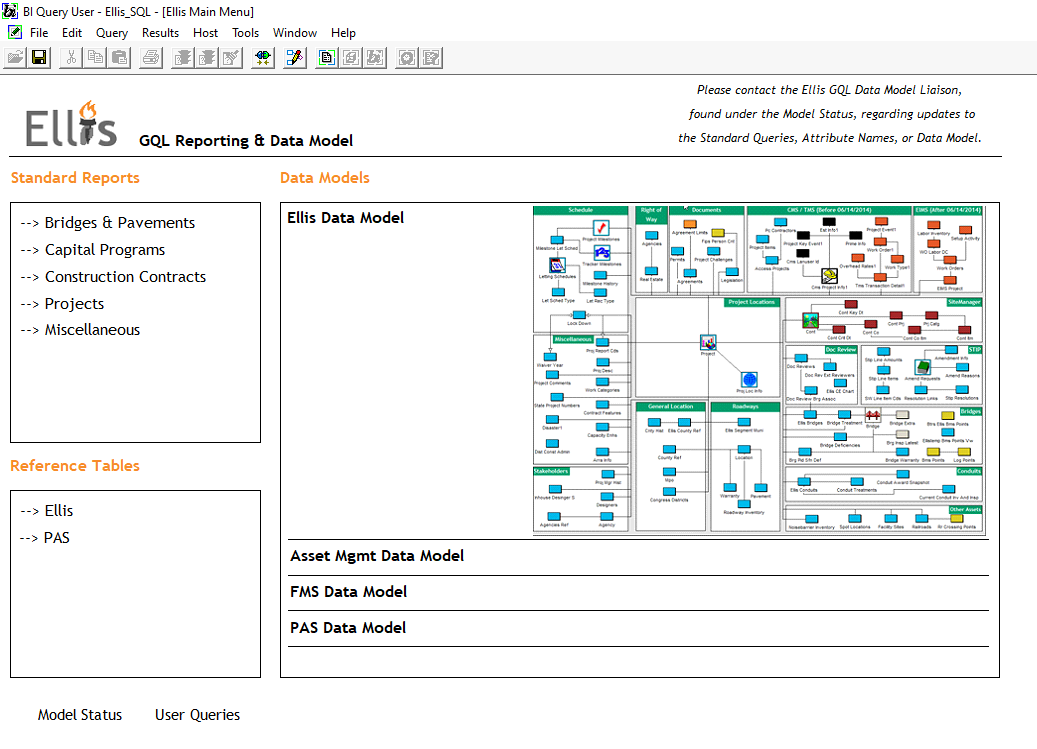

Note the color coordination seems to align with the databases available in  
itcsqlp31;

Green - Collector, mostly culvert data,

Likely the `'COLLECTOR'` database, currently don't have access.

Gold - BTRS - 

Pink - Road Inventory

Probably mostly from `'RIMS'` - again, no access

Blue - Ellis

Again, there's a DB named `'ELLIS'`, but I don't have access

Grey - SMS

No idea where this lives.

In [20]:
# //TODO - Likely need access to the above tables to migrate historical data

## BMS

Think this is the oldest in the sequence, if you try to connect to it now,
it now longer works.

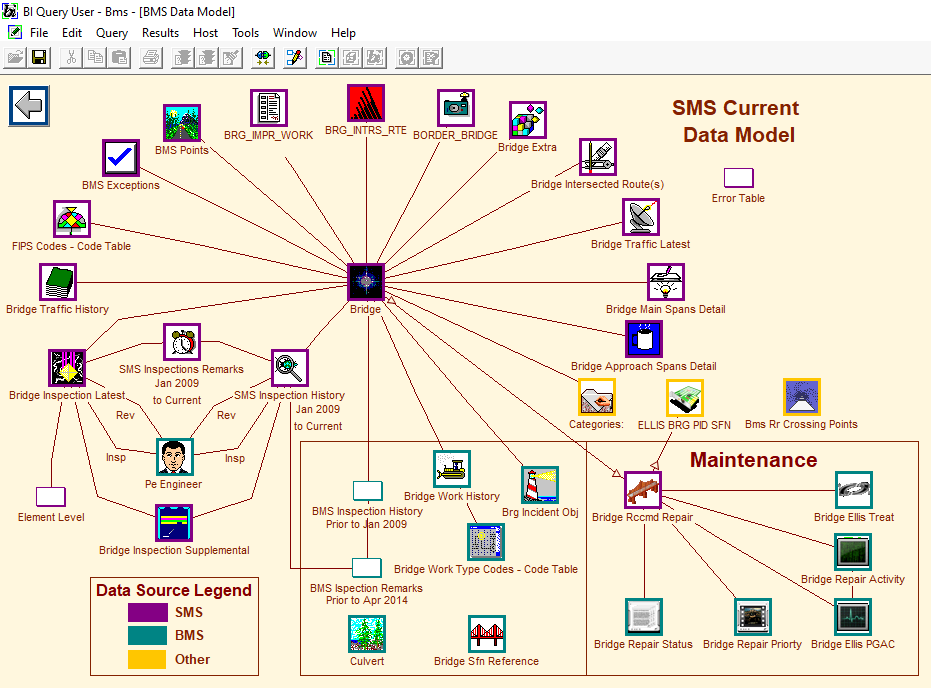

## SMS

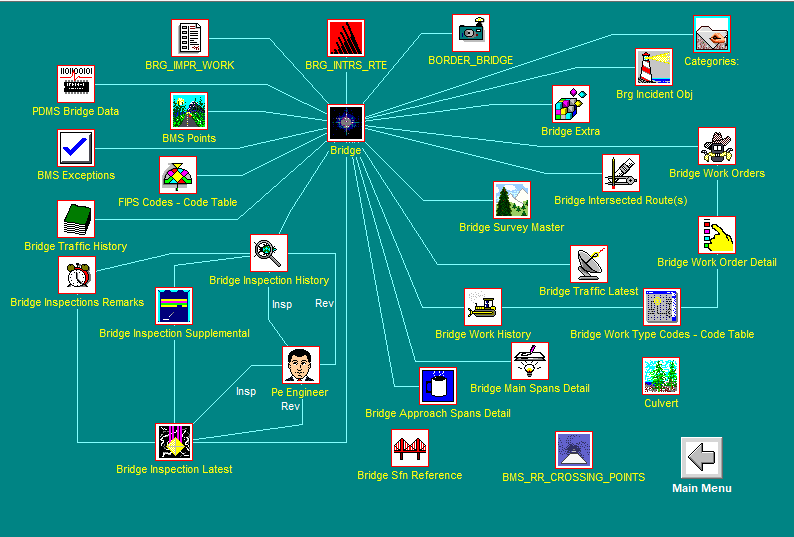

Seems like the newer system, queries actually run,

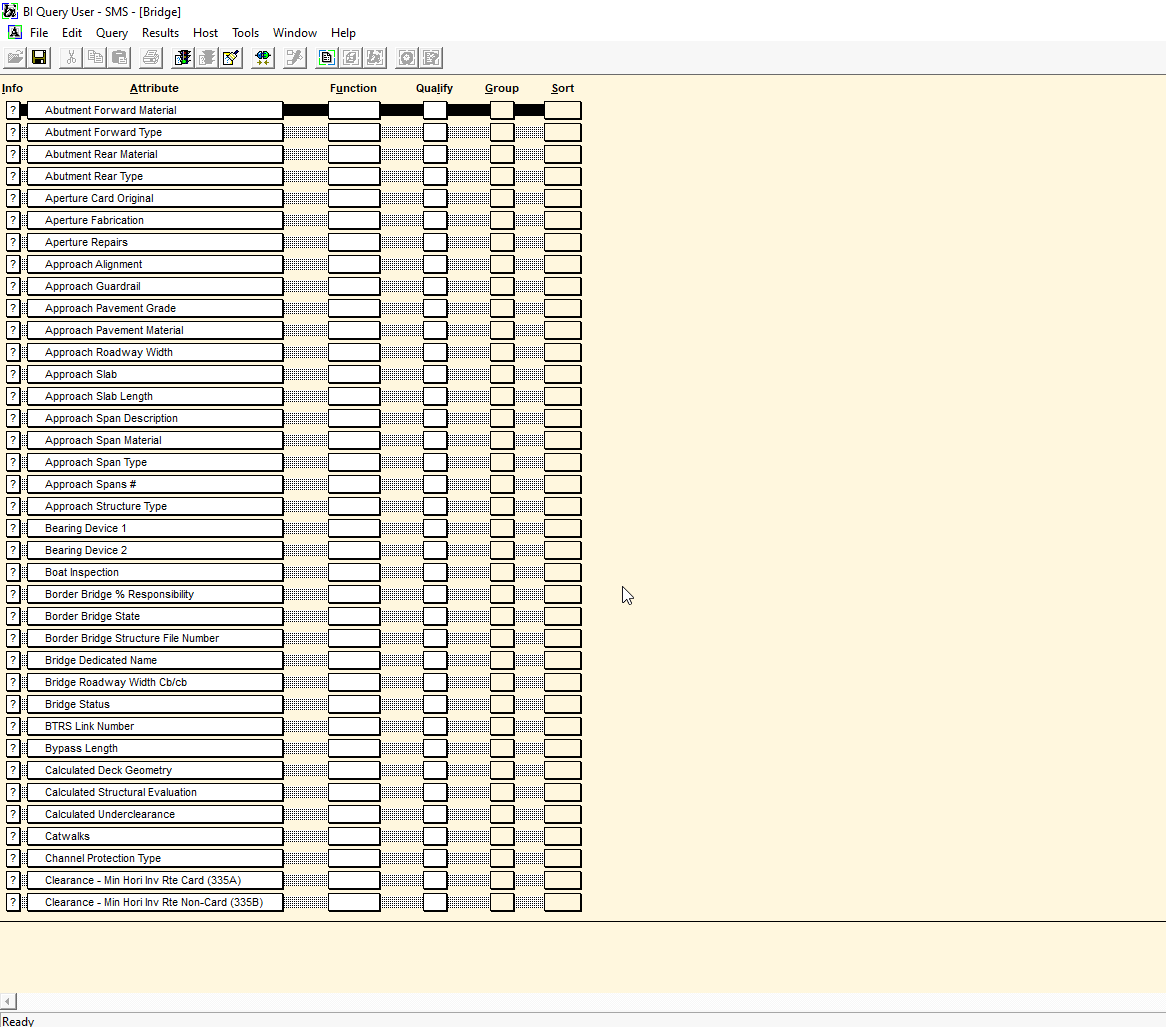

to build out the above table the following query is generated,

```sql
SELECT
    BRG_SUBS.ABUT_FWD_MATL_CD,
    BRG_SUBS.ABUT_FWD_TYP_CD,
    BRG_SUBS.ABUT_REAR_MATL_CD,
    BRG_SUBS.ABUT_REAR_TYP_CD,
    BRG_SPCL_FEAT.APERTURE_ORIG_SW,
    BRG_SPCL_FEAT.APERTURE_FABR_SW,
    BRG_SPCL_FEAT.APERTURE_REP_SW,
    BRIDGE.APPRH_ALGN_CD,
    BRIDGE.APPRH_GUARDRAIL_CD,
    -- [many more fields...]
    BRIDGE.WEARING_SURF_CD,
    YEAR(BRIDGE.MAJ_RECON_DT),
    COUNT(BRIDGE.SFN)
FROM 
    {oj SMS_BRG_INSP_FACTOR BRG_INSP_FACTOR
    INNER JOIN SMS_BRIDGE BRIDGE ON BRG_INSP_FACTOR.SFN = BRIDGE.SFN
    INNER JOIN SMS_BRG_SPCL_FEAT BRG_SPCL_FEAT ON BRIDGE.SFN = BRG_SPCL_FEAT.SFN
    INNER JOIN SMS_BRG_SUBS BRG_SUBS ON BRIDGE.SFN = BRG_SUBS.SFN
    INNER JOIN SMS_BRG_CONST BRG_CONST ON BRIDGE.SFN = BRG_CONST.SFN
    LEFT OUTER JOIN SMS_BORDER_BRIDGE BORDER_BRIDGE ON BRIDGE.SFN = BORDER_BRIDGE.SFN }
WHERE 
    BRIDGE.BRG_STAT_CD IN ('A', 'E');
```

Now to try to hunt down the listed tables.  There's a server that hosts TIMs,

In [19]:
import pandas as pd
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

# Connection string
connection_string = (
    r"Driver=ODBC Driver 17 for SQL Server;"
    r"Server=doticsqlp31;"
    r"Database=TIMS;"  # Use 'master' to access server-level metadata
    r"Trusted_Connection=yes;"
)

# Create engine
connection_url = URL.create("mssql+pyodbc", query={"odbc_connect": connection_string})
engine = create_engine(connection_url)

# Query to list databases
query = text("SELECT name FROM sys.databases")

# Execute and load into DataFrame
with engine.connect() as conn:
    df = pd.read_sql(query, conn)

print(df)

                         name
0                 AD_METADATA
1                      Apollo
2    AppropriationsAccounting
3                        ARMS
4                         ARS
..                        ...
110                  tims_app
111              TIMS_CLASSIC
112              TIMS_IIS_APP
113                      TSMO
114                      WZDB

[115 rows x 1 columns]


GQL frequently queries an "SMS" table, but that's not included in any of  
the databases available on doticsqlp31.

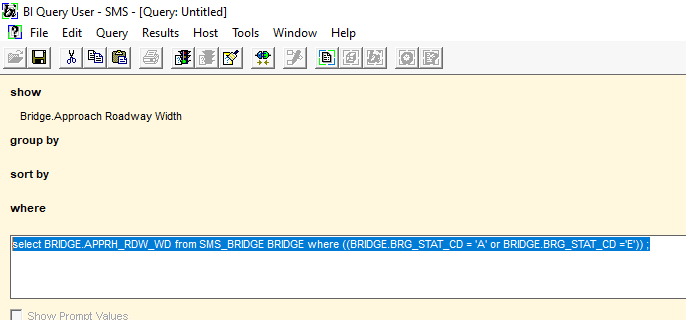

['AD_METADATA',
 'Apollo',
 'AppropriationsAccounting',
 'ARMS',
 'ARS',
 'AVIFuelMasterPlusSQL',
 'AwpEvents',
 'BridgePhoto',
 'CADD_GIS',
 'CALLACCOUNTING',
 'cashforecasting',
 'CitrixODOTLogging',
 'CitrixODOTMonitoring',
 'CitrixODOTSite',
 'CitrixProvisioning',
 'CIV',
 'COLLECTOR',
 'Core_v2',
 'CPQ',
 'CSSCES',
 'CTXCloud',
 'DataGovernance',
 'DBAdmin',
 'Desktopcentral',
 'DPXE5',
 'DTIMS_BA_PLAN',
 'DTIMS_BA_REVIEW',
 'DTIMS_BA_STAGE',
 'dTIMSAuth',
 'ELLIS',
 'EstimatingSchedule',
 'ExpressDB',
 'FalconGeoMS',
 'FalconTSRV',
 'FARS',
 'FuelMasterPlusSQL',
 'FuelMasterPlusSQL_ETL',
 'geocue',
 'GEOLIMS',
 'GIS',
 'GoFormzQueue',
 'HIMS',
 'Horizon',
 'HorizonLibrary',
 'HP_Gateway',
 'HPACIRM',
 'HPACJA',
 'HPACJATEST',
 'HPIPSC',
 'HPWJA',
 'HTETPS',
 'Innovate2',
 'Inventory',
 'ITE_Trip_Gen_Start',
 'KBase',
 'KEPI',
 'KeyLAB',
 'Logs_v2',
 'master',
 'Mediasite7DB',
 'Mediasite7Site',
 'Mediasite87DB',
 'Mediasite87Site',
 'Mediasite8DB',
 'Mediasite8Site',
 'METS',
 'M

## TMS - Not Sure what this is

Example query it's used in, determining a structure's work history

```SQL
select 
	distinct BYSH_TMS_WORK_HST_VW.STRUCTURE_FILE_NBR, 
	BYSH_TMS_WORK_HST_VW.PID_NBR, 
	BYSH_TMS_WORK_HST_VW.STATE_PROJECT_NBR, 
	BYSH_TMS_WORK_HST_VW.TRANSACTION_YEAR, 
	BYSH_TMS_WORK_HST_VW.PROGRAM_ACTIVITY_CD, 
	BYSH_TMS_WORK_HST_VW.PROGRAM_ACTIVITY_DESC_TXT, 
	SUM (BYSH_TMS_WORK_HST_VW.COST_AMT) 
from 
	BYSH_TMS_WORK_HST_VW 
where 
	(
		BYSH_TMS_WORK_HST_VW.STRUCTURE_FILE_NBR = «Structure File Nbr»
	) 
group by 
	BYSH_TMS_WORK_HST_VW.STRUCTURE_FILE_NBR, 
	BYSH_TMS_WORK_HST_VW.TRANSACTION_YEAR, 
	BYSH_TMS_WORK_HST_VW.PID_NBR, 
	BYSH_TMS_WORK_HST_VW.PROGRAM_ACTIVITY_CD, 
	BYSH_TMS_WORK_HST_VW.STATE_PROJECT_NBR, 
	BYSH_TMS_WORK_HST_VW.PROGRAM_ACTIVITY_DESC_TXT 
order by 
	1, 
	4, 
	2, 
	5 
;
```

# Assetwise - Modern Values, Not Covered Here

See assetwise notebook.

# Data Warehouse Connection

In [1]:
import pandas as pd
from sqlalchemy import create_engine, inspect, text
from sqlalchemy.engine import URL

# --- CONFIGURATION ---
# Updated with your successful findings
SERVER_NAME = 'DOTWAREHOUSEPRD'
DATABASE_NAME = 'Warehouse'
TARGET_TABLE = 'SMS_BRIDGE'  # The main bridge inventory table

print(f"--- STARTING SQL CONTEXT GENERATION ---\n")

def get_db_engine():
    """Establishes connection to the SQL Server."""
    connection_string = (
        f"Driver=ODBC Driver 17 for SQL Server;"
        f"Server={SERVER_NAME};"
        f"Database={DATABASE_NAME};"
        f"Trusted_Connection=yes;"
    )
    # Ensure pyodbc is installed in your environment
    connection_url = URL.create("mssql+pyodbc", query={"odbc_connect": connection_string})
    return create_engine(connection_url)

def get_table_schema(engine, table_name):
    """
    Retrieves column names and data types from the database.
    """
    try:
        inspector = inspect(engine)
        
        # Robustness Check: Does the table exist?
        if not inspector.has_table(table_name):
            print(f"  ! WARNING: Table '{table_name}' not found in '{DATABASE_NAME}'.")
            
            # Diagnostic: Help find the right table if the name is slightly different in Warehouse
            print("  ! Scanning for alternatives in Warehouse...")
            all_tables = inspector.get_table_names()
            # Filter for likely candidates
            candidates = [t for t in all_tables if 'BRIDGE' in t or 'SMS' in t]
            if candidates:
                print(f"  ! Did you mean one of these? {candidates[:5]}")
            
            raise ValueError(f"Table '{table_name}' does not exist in database '{DATABASE_NAME}'.")

        # Get real columns
        columns = inspector.get_columns(table_name)
        df = pd.DataFrame(columns)
        
        # Ensure comment column exists for consistency
        if 'comment' not in df.columns:
            df['comment'] = None
            
        return df[['name', 'type', 'comment']]
        
    except Exception as e:
        print(f"  ! ERROR accessing DB schema: {e}")
        raise e

def get_unique_values(engine, table_name, column_name, limit=5):
    """
    Fetches sample values for categorical columns to aid LLM understanding.
    """
    try:
        # Note: In production, input validation should be used here to prevent SQL injection,
        # but for an internal metadata tool, string interpolation is acceptable.
        query = text(f"SELECT DISTINCT TOP {limit} {column_name} FROM {table_name} WHERE {column_name} IS NOT NULL")
        with engine.connect() as conn:
            result = conn.execute(query).fetchall()
            return [row[0] for row in result]
    except Exception as e:
        # Silent fail for sampling is fine
        return []

# ==========================================
# EXECUTION
# ==========================================

if __name__ == "__main__":
    try:
        # 1. Establish Connection
        engine = get_db_engine()
        print(f"Connected to {SERVER_NAME}/{DATABASE_NAME}")

        # 2. Get the structure
        print(f"Phase 1: Extracting Schema for table '{TARGET_TABLE}'...")
        df_schema = get_table_schema(engine, TARGET_TABLE)
        
        # 3. Enrich with sample data
        print("Phase 2: Sampling distinct values for categorical context...")
        
        context_lines = []
        context_lines.append(f"TABLE: {TARGET_TABLE}")
        context_lines.append(f"DESCRIPTION: Main inventory table for bridge structures.")
        context_lines.append("-" * 40)
        
        # Columns often requiring context for LLMs (Codes, IDs, Types)
        # Expanded list based on typical bridge inventory needs
        categorical_cols = [
            'COUNTY_CD', 'DISTRICT', 'MAIN_MATL_CD', 'ROUTE_TYPE', 'BRG_STAT_CD',
            'LAT_DEG_MM_SEC', 'LNGTD_DEG_MM_SEC', 'INVENT_HWY_SYS_CD'
        ]

        for _, row in df_schema.iterrows():
            col_name = row['name']
            col_type = row['type']
            
            # Build the definition string
            line = f"- {col_name} ({col_type})"
            
            # For specific columns, grab samples to help the AI understand the data format
            if col_name in categorical_cols or 'TYPE' in col_name or 'CD' in col_name:
                samples = get_unique_values(engine, TARGET_TABLE, col_name)
                if samples:
                    line += f" -> Samples: {samples}"
                    
            # Add database comments if they exist
            if row['comment']:
                 line += f" // {row['comment']}"
                 
            context_lines.append(line)

        # 4. Output the Final Artifact
        print("\n" + "="*50)
        print("GENERATED AI CONTEXT BLOCK")
        print("Paste this into your LLM System Prompt")
        print("="*50)
        
        final_context = "\n".join(context_lines)
        print(final_context)
        
        print("\n" + "="*50)

    except Exception as e:
        print(f"\nCRITICAL ERROR: {e}")

--- STARTING SQL CONTEXT GENERATION ---

Connected to DOTWAREHOUSEPRD/Warehouse
Phase 1: Extracting Schema for table 'SMS_BRIDGE'...
Phase 2: Sampling distinct values for categorical context...

GENERATED AI CONTEXT BLOCK
Paste this into your LLM System Prompt
TABLE: SMS_BRIDGE
DESCRIPTION: Main inventory table for bridge structures.
----------------------------------------
- SFN (VARCHAR(7) COLLATE "SQL_Latin1_General_CP1_CI_AS")
- COUNTY_CD (VARCHAR(3) COLLATE "SQL_Latin1_General_CP1_CI_AS") -> Samples: ['GAL', 'WOO', '', 'GRE', 'POR']
- ROUTE (VARCHAR(5) COLLATE "SQL_Latin1_General_CP1_CI_AS")
- SLM (VARCHAR(5) COLLATE "SQL_Latin1_General_CP1_CI_AS")
- SLK (VARCHAR(6) COLLATE "SQL_Latin1_General_CP1_CI_AS")
- DISTRICT (VARCHAR(2) COLLATE "SQL_Latin1_General_CP1_CI_AS") -> Samples: ['11', '08', '07', '12', '02']
- BARS_CD (VARCHAR(1) COLLATE "SQL_Latin1_General_CP1_CI_AS") -> Samples: ['0']
- FIPS_CD (VARCHAR(5) COLLATE "SQL_Latin1_General_CP1_CI_AS") -> Samples: ['', '04220', '59822